# Improvements over Baseline — Grupo Bimbo


- **Improvement 1:** Return-rate features
- **Improvement 2:** Spatial cluster features  
- **Improvement 3:** Product-channel interaction features

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_log_error

PROJECT_ROOT = Path("..").resolve()
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "csv"

BASELINE_RMSLE = 0.4646

print("Ready.")

Ready.


## 1. Load Data

In [5]:
train_full = pd.read_csv(
    RAW_DIR / "train.csv",
    dtype={"Semana": "int8", "Agencia_ID": "int32", "Canal_ID": "int8",
           "Ruta_SAK": "int32", "Cliente_ID": "int32", "Producto_ID": "int32",
           "Venta_uni_hoy": "int32", "Dev_uni_proxima": "int32", "Demanda_uni_equil": "int32"},
    usecols=["Semana", "Agencia_ID", "Canal_ID", "Ruta_SAK", "Cliente_ID",
             "Producto_ID", "Venta_uni_hoy", "Dev_uni_proxima", "Demanda_uni_equil"]
)

np.random.seed(42)
sample_agencies = np.random.choice(train_full["Agencia_ID"].unique(), size=50, replace=False)
train = train_full[train_full["Agencia_ID"].isin(sample_agencies)].copy()
del train_full

print(f"Rows: {len(train):,}")
print(f"Weeks: {sorted(train['Semana'].unique())}")

Rows: 8,820,263
Weeks: [np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7), np.int8(8), np.int8(9)]


In [6]:
import re

def build_lag_features(df):
    key = ["Producto_ID", "Agencia_ID", "Cliente_ID"]
    df = df.sort_values(["Semana"] + key).copy()
    for lag in [1, 2, 3]:
        df[f"demand_lag{lag}"] = df.groupby(key)["Demanda_uni_equil"].shift(lag)
    df["demand_roll2"] = (
        df.groupby(key)["Demanda_uni_equil"]
        .transform(lambda x: x.shift(1).rolling(2, min_periods=1).mean())
    )
    return df

def add_return_rate_features(df):
    key = ["Producto_ID", "Agencia_ID", "Canal_ID"]
    df = df.sort_values(["Semana"] + key).copy()
    df["cum_dev"] = df.groupby(key)["Dev_uni_proxima"].transform(
        lambda x: x.shift(1).expanding().sum()
    )
    df["cum_venta"] = df.groupby(key)["Venta_uni_hoy"].transform(
        lambda x: x.shift(1).expanding().sum()
    )
    df["hist_return_rate"] = df["cum_dev"] / (df["cum_venta"] + 1)
    return df

def add_spatial_features(df, interim_dir):
    geo = pd.read_parquet(interim_dir / "agency_geolocation_features.parquet")
    geo = geo[["Agencia_ID", "geo_cluster", "dist_to_hub_km"]].drop_duplicates()
    df = df.merge(geo, on="Agencia_ID", how="left")
    return df

def add_product_channel_features(df, interim_dir):
    products = pd.read_parquet(interim_dir / "product_regex_features.parquet")
    products = products[["Producto_ID", "product_weight_g", "product_units_per_pack", 
                          "product_weight_per_unit_g"]].drop_duplicates()
    df = df.merge(products, on="Producto_ID", how="left")
    pc_stats = (
        df[df["Semana"] <= 7]
        .groupby(["Producto_ID", "Canal_ID"])["Demanda_uni_equil"]
        .agg(["median", "std"])
        .reset_index()
        .rename(columns={"median": "pc_median_demand", "std": "pc_std_demand"})
    )
    df = df.merge(pc_stats, on=["Producto_ID", "Canal_ID"], how="left")
    return df

train = build_lag_features(train)
train = add_return_rate_features(train)
train = add_spatial_features(train, INTERIM_DIR)
train = add_product_channel_features(train, INTERIM_DIR)
train_model = train.dropna(subset=["demand_lag1", "demand_lag2"])

print(f"Rows ready: {len(train_model):,}")
print(f"Columns: {len(train_model.columns)}")

Rows ready: 3,827,882
Columns: 23


## 3. Train Improved Model & Compare

In [7]:
FEATURES_IMPROVED = [
    "Semana", "Agencia_ID", "Canal_ID", "Ruta_SAK",
    "Cliente_ID", "Producto_ID",
    "demand_lag1", "demand_lag2", "demand_lag3", "demand_roll2",
    "hist_return_rate", "geo_cluster", "dist_to_hub_km",
    "product_weight_g", "product_units_per_pack", "product_weight_per_unit_g",
    "pc_median_demand", "pc_std_demand",
]

TARGET = "Demanda_uni_equil"

train_data = train_model[train_model["Semana"] <= 7]
val_data = train_model[train_model["Semana"] >= 8]

X_train = train_data[FEATURES_IMPROVED].fillna(-1)
y_train = np.log1p(train_data[TARGET])
X_val = val_data[FEATURES_IMPROVED].fillna(-1)
y_val = val_data[TARGET]

model_improved = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

model_improved.fit(X_train, y_train, verbose=100)

preds_improved = np.expm1(model_improved.predict(X_val)).clip(0)
rmsle_improved = np.sqrt(mean_squared_log_error(y_val, preds_improved))

print(f"Baseline RMSLE:  {BASELINE_RMSLE:.4f}")
print(f"Improved RMSLE:  {rmsle_improved:.4f}")
print(f"Improvement:     {BASELINE_RMSLE - rmsle_improved:.4f}")

Baseline RMSLE:  0.4646
Improved RMSLE:  0.4624
Improvement:     0.0022


## 4. Comparison & Observations

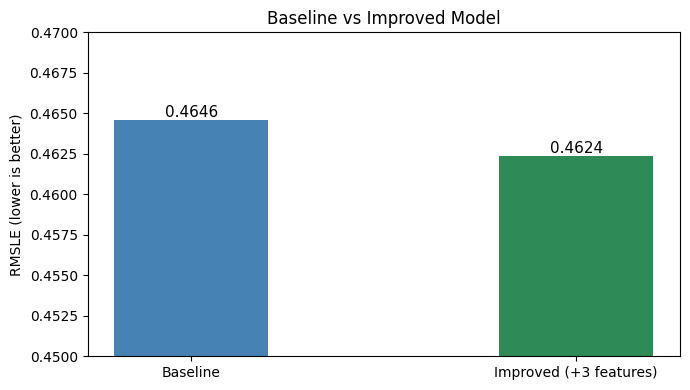

In [8]:
models = ["Baseline", "Improved (+3 features)"]
rmsles = [BASELINE_RMSLE, rmsle_improved]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(models, rmsles, color=["steelblue", "seagreen"], width=0.4)
ax.set_ylim(0.45, 0.47)
ax.set_ylabel("RMSLE (lower is better)")
ax.set_title("Baseline vs Improved Model")
for bar, val in zip(bars, rmsles):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f"{val:.4f}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()